### Piotr Przymus 127902
# Laboratorium 6: Porównanie modeli klasyfikacyjnych i ocena niepewności estymacji (Breast Cancer)

Zbiór: **Breast Cancer Wisconsin (Diagnostic)**.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from IPython.display import display


## 1. Wczytanie i opis zbioru danych

In [3]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
X = data.data
y = data.target

print(f"Liczba próbek: {X.shape[0]}")
print(f"Liczba cech: {X.shape[1]}")
print(f"Klasy: {data.target_names}")
print(f"Rozkład klas: {dict(zip(*np.unique(y, return_counts=True)))}")
print(f"Brakujące wartości: {np.isnan(X).sum()}")

Liczba próbek: 569
Liczba cech: 30
Klasy: ['malignant' 'benign']
Rozkład klas: {np.int64(0): np.int64(212), np.int64(1): np.int64(357)}
Brakujące wartości: 0


Zbiór zawiera 569 próbek opisanych 30 cechami numerycznymi. Zadaniem jest klasyfikacja guza jako **łagodny (benign)** lub **złośliwy (malignant)**.

## 2. Wizualizacja separowalności klas

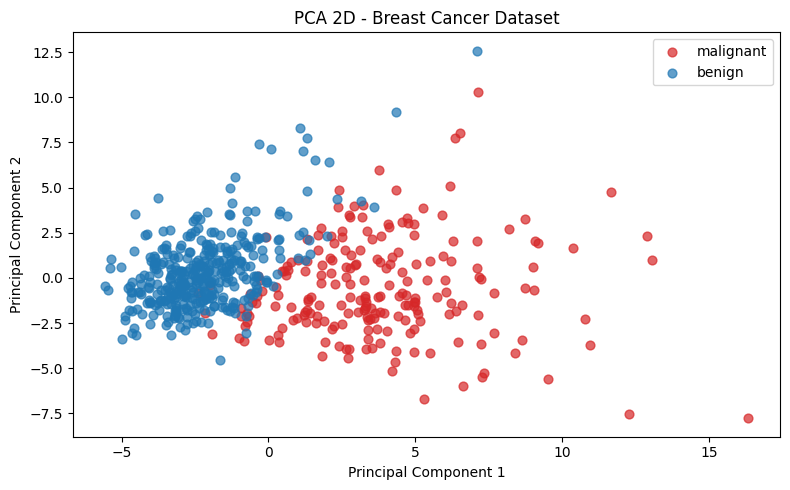

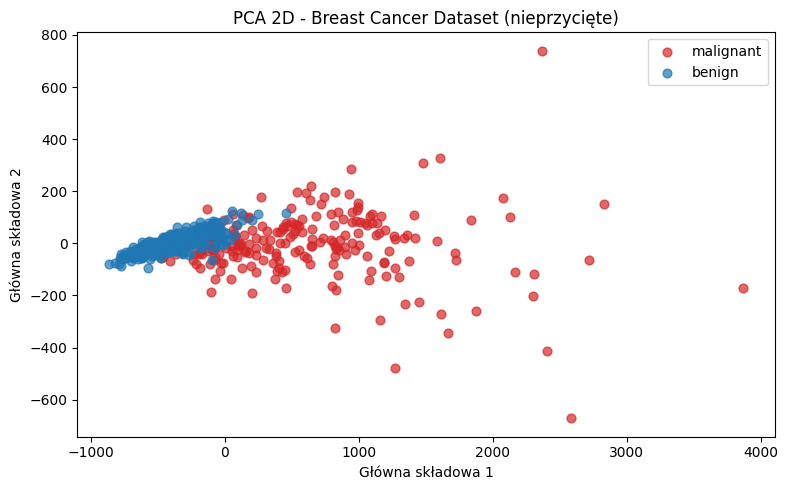

In [ ]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(StandardScaler().fit_transform(X))

fig, ax = plt.subplots(figsize=(8, 5))
for label, name, color in [(0, "malignant", "tab:red"), (1, "benign", "tab:blue")]:
    mask = y == label
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], label=name, alpha=0.7, s=40, c=color)

ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_title("PCA 2D - Breast Cancer Dataset")
ax.legend()
plt.tight_layout()
plt.show()

pca_2 = PCA(n_components=2, random_state=42)
X_pca_2 = pca_2.fit_transform(X)

fig, ax = plt.subplots(figsize=(8, 5))
for label, name, color in [(0, "malignant", "tab:red"), (1, "benign", "tab:blue")]:
    mask = y == label
    ax.scatter(X_pca_2[mask, 0], X_pca_2[mask, 1], label=name, alpha=0.7, s=40, c=color)

ax.set_xlabel("Główna składowa 1")
ax.set_ylabel("Główna składowa 2")
ax.set_title("PCA 2D - Breast Cancer Dataset - bez skalowania")
ax.legend()
plt.tight_layout()
plt.show()  



## 3. Walidacja krzyżowa i porównanie modeli

Dla każdego modelu wykonuję 5-krotną walidację krzyżową. Obliczam średnią dokładność (accuracy) oraz odchylenie standardowe wyników z poszczególnych foldów - ta druga miara opisuje stabilność modelu i niepewność estymacji.

Wyniki walidacji krzyżowej:


,Model,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Średnia accuracy,Odch. stand.
0,SVM,0.9825,0.9825,0.9737,0.9912,0.9735,0.9807,0.0066
1,Logistic Regression,0.9737,0.9825,0.9649,0.9912,0.9735,0.9771,0.0090
2,KNN,0.9474,0.9825,0.9649,0.9737,0.9292,0.9595,0.0191
3,Random Forest,0.9561,0.9649,0.9386,0.9649,0.9646,0.9578,0.0102


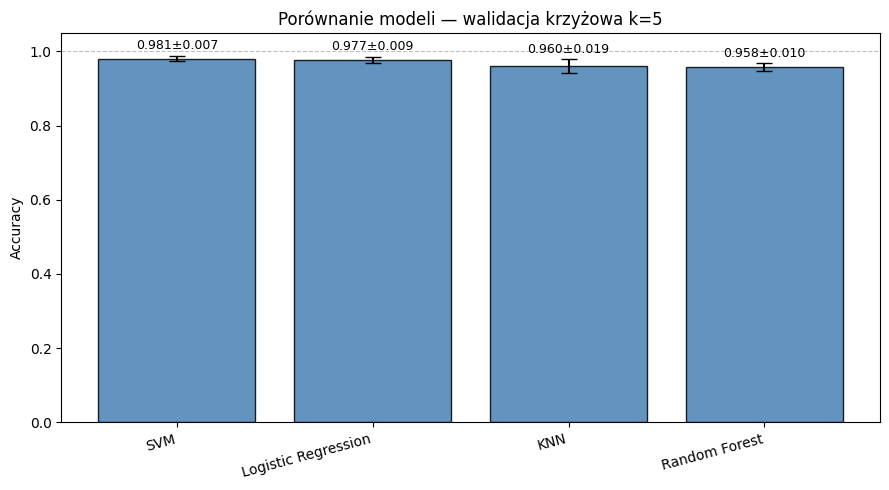

In [5]:
from IPython.display import display

K = 5
kf = KFold(n_splits=K, shuffle=True, random_state=42)

models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000, random_state=42)),
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=100, random_state=42
    ),
    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(random_state=42)),
    ]),
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", KNeighborsClassifier()),
    ]),
}

results = []
fold_details = {}

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=kf, scoring="accuracy")

    fold_details[name] = scores

    results.append({
        "Model": name,
        "Fold 1": scores[0],
        "Fold 2": scores[1],
        "Fold 3": scores[2],
        "Fold 4": scores[3],
        "Fold 5": scores[4],
        "Średnia accuracy": scores.mean(),
        "Odch. stand.": scores.std(),
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Średnia accuracy",
    ascending=False
).reset_index(drop=True)

print("Wyniki walidacji krzyżowej:")
display(
    results_df.style.format({
        "Fold 1": "{:.4f}",
        "Fold 2": "{:.4f}",
        "Fold 3": "{:.4f}",
        "Fold 4": "{:.4f}",
        "Fold 5": "{:.4f}",
        "Średnia accuracy": "{:.4f}",
        "Odch. stand.": "{:.4f}",
    })
    .background_gradient(
        subset=["Średnia accuracy"],
        cmap="Greens"
    )
    .set_caption("Porównanie modeli (5-fold Cross Validation)")
)

fig, ax = plt.subplots(figsize=(9, 5))

x_pos = np.arange(len(results_df))
means = results_df["Średnia accuracy"].values
stds = results_df["Odch. stand."].values
labels = results_df["Model"].values

bars = ax.bar(
    x_pos,
    means,
    yerr=stds,
    capsize=6,
    color="steelblue",
    edgecolor="black",
    alpha=0.85,
)

ax.set_xticks(x_pos)
ax.set_xticklabels(labels, rotation=15, ha="right")
ax.set_ylabel("Accuracy")
ax.set_title(f"Porównanie modeli — walidacja krzyżowa k={K}")
ax.set_ylim(0, 1.05)
ax.axhline(
    1.0,
    color="gray",
    linestyle="--",
    linewidth=0.8,
    alpha=0.5,
)

for bar, m, s in zip(bars, means, stds):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        m + s + 0.01,
        f"{m:.3f}±{s:.3f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.tight_layout()
plt.show()

Najlepszym modelem okazuje się zatem SVM, osiągnął on najlepszą średnią dokładność i najmniejsze odchylenie standardowe - przewyższa inne zarówno pod względem precyzyjności, jak i stabilności.

Zbiór jest dobrze rozdzielny, dlatego wszystkie modele radzą sobie dobrze, a różnice dotyczą głównie stabilności estymacji.

## 4. Wnioski

### Co oznacza, że zbiór danych jest „dobrze rozdzielny” w kontekście klasyfikacji?

Zbiór jest dobrze rozdzielny, gdy obserwacje różnych klas tworzą w przestrzeni cech wyraźnie oddzielone regiony. Na wykresie PCA tego zbioru widać, że punkty malignant i benign tworzą stosunkowo rozłączne skupiska - modele mogą więc w miarę łatwo znaleźć granicę decyzyjną. Skutkuje to wysoką dokładnością we wszystkich testowanych modelach.

### Czy model o wysokiej średniej accuracy, ale bardzo dużym odchyleniu standardowym można uznać za stabilny?

Nie, ponieważ wysoka średnia dokładności mówi o dobrym wyniku „w uśrednieniu”, ale duże odchylenie standardowe oznacza, że wyniki silnie zależą od tego, które próbki trafiły do zbioru testowego w danym foldzie. Taki model uznaje się za niestabilny. W tym przypadku KNN ma nieco niższą średnią dokładność i największe odchylenie standardowe spośród modeli - jest najmniej przewidywalny.

### Co mierzy odchylenie standardowe wyników w cross-validation i jak interpretujesz niską wartość tej miary?

Odchylenie standardowe mierzy rozrzut wyników accuracy między foldami. Niska wartość (np. ok. 0,0066 dla SVM) oznacza, że model osiąga podobne wyniki niezależnie od podziału danych - estymacja jakości jest stabilna, a niepewność estymatora jest mała.

### Co rozumiemy przez „niepewność estymacji” w kontekście oceny jakości modelu?

Niepewność estymacji to zmienność oceny jakości modelu wynikająca z tego, że dysponujemy próbą losową. Inny losowy podział train/test dałby nieco inny wynik. Cross-validation pozwala zmierzyć tę zmienność - średnia daje oczekiwany wynik, a odchylenie standardowe mówi, jak bardzo ten wynik zmienia się między foldami.

### Podaj przykład sytuacji, w której dwa modele mają podobną średnią accuracy, ale różną niepewność estymacji. Który model wybrałbyś i dlaczego?

W tym zbiorze Random Forest i KNN osiągają podobną średnią accuracy (ok. 0,96), ale KNN ma wyraźnie większe odchylenie standardowe. Wybrałbym Random Forest, ponieważ przy porównywalnej skuteczności daje bardziej stabilne wyniki między foldami - mniejsza niepewność estymacji oznacza większą pewność, że model będzie działał podobnie na nowych danych.